<a href="https://colab.research.google.com/github/11465005-tech/ceva/blob/main/pipelined_nn_CVAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 中文版 Pipelined Neural Networks v4
**v4 核心改動：NNword 和 NNmod 真正串接（End-to-End Pipeline）**

| 版本 | NNword→NNmod 串接方式 |
|------|----------------------|
| v1/v2/v3 | 分開訓練，預測時才串接 |
| **v4** | **NNmod 訓練時直接呼叫 NNword forward，梯度一路反傳** |
| **v5** | **詞向量訓練語料改用 CVAT 長文本（jieba 斷詞），NNword/NNmod 串接方式沿用 v4，不變** |

**資料集：** CVAW（單詞）+ CVAP（短語）用於 NNword/NNmod 訓練與評估；CVAT（長文本）僅用於訓練詞向量，訓練:測試 = 8:2
**評估指標：** MAE、MSE、Pearson r（Chinese EmoBank 論文）+ Kendall τ、Spearman ρ（Pipelined NN 論文）

## 0. 安裝套件

In [1]:
!pip install gensim torch numpy pandas scikit-learn matplotlib scipy jieba -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.5 MB/s eta 0:00:00


## 1. 掛載 Google Drive 並載入資料集

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau, spearmanr, pearsonr

# ---- 路徑設定（依實際路徑修改）----
CVAW_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAW_SD/CVAW_all_SD.csv'
CVAP_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAP_SD/CVAP_all_SD.csv'
CVAT_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAT_SD/CVAT_all_SD.csv'  # 長文本，欄位: Text, Valence_Mean, Arousal_Mean, Category

def read_csv_robust(path, sep='\t'):
    """依序嘗試常見編碼，避免 CVAT 這種多來源拼接檔案的編碼不一致問題導致整檔讀取失敗"""
    for enc in ['utf-8', 'utf-8-sig', 'big5', 'gb18030', 'cp950']:
        try:
            df = pd.read_csv(path, sep=sep, encoding=enc)
            print(f'  → {path.split("/")[-1]} 使用編碼: {enc}')
            return df
        except (UnicodeDecodeError, UnicodeError):
            continue
    # 都失敗的話，用 utf-8 並把讀不了的字元換成替代符號，不讓整個檔案讀取中斷
    print(f'  → {path.split("/")[-1]} 所有編碼嘗試失敗，改用 utf-8 + errors="replace"（少量字元可能變成亂碼，不影響整體訓練）')
    return pd.read_csv(path, sep=sep, encoding='utf-8', encoding_errors='replace')

cvaw = read_csv_robust(CVAW_PATH)
cvap = read_csv_robust(CVAP_PATH)
cvat = read_csv_robust(CVAT_PATH)
print(f'CVAW 筆數: {len(cvaw)}  CVAP 筆數: {len(cvap)}  CVAT 筆數: {len(cvat)}')

  → CVAW_all_SD.csv 使用編碼: utf-8
  → CVAP_all_SD.csv 使用編碼: utf-8
  → CVAT_all_SD.csv 所有編碼嘗試失敗，改用 utf-8 + errors="replace"（少量字元可能變成亂碼，不影響整體訓練）
CVAW 筆數: 5512  CVAP 筆數: 2250  CVAT 筆數: 2971


## 2. 資料前處理

In [4]:
def normalize_va(df, val_col='Valence_Mean', aro_col='Arousal_Mean'):
    """VA 分數 [1,9] → [0,1]，並自動清除數值欄位無法轉換的髒資料列
    （例如 CVAT 原始檔案中偶爾出現的欄位錯位/跨列黏在一起的壞資料）"""
    df = df.copy()
    before = len(df)
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    df[aro_col] = pd.to_numeric(df[aro_col], errors='coerce')
    df = df.dropna(subset=[val_col, aro_col]).reset_index(drop=True)
    dropped = before - len(df)
    if dropped > 0:
        print(f'  ⚠ 清除 {dropped} 筆髒資料列（{val_col}/{aro_col} 無法轉為數值）')
    df['valence'] = (df[val_col] - 1) / 8.0
    df['arousal'] = (df[aro_col] - 1) / 8.0
    return df

cvaw = normalize_va(cvaw)
cvap = normalize_va(cvap)
cvat = normalize_va(cvat)  # CVAT 欄位與 CVAW/CVAP 相同慣例，可直接沿用

# CVAP 短語切割：修飾詞 + 核心詞（核心詞需在 CVAW 中）
cvaw_word_set = set(cvaw['Word'].tolist())

def split_phrase(phrase, cvaw_words):
    for mod_len in [1, 2, 3, 4]:
        if len(phrase) > mod_len:
            mod  = phrase[:mod_len]
            core = phrase[mod_len:]
            if core in cvaw_words:
                return mod, core
    return None, None

mods, cores = [], []
for phrase in cvap['Phrase']:
    m, c = split_phrase(phrase, cvaw_word_set)
    mods.append(m); cores.append(c)

cvap['modifier']  = mods
cvap['core_word'] = cores
cvap_aligned = cvap.dropna(subset=['modifier','core_word']).copy()
print(f'CVAP 對齊: {len(cvap_aligned)} / {len(cvap)} 筆')

# 8:2 切分
cvaw_train, cvaw_test = train_test_split(cvaw,         test_size=0.2, random_state=42)
cvap_train, cvap_test = train_test_split(cvap_aligned, test_size=0.2, random_state=42)
print(f'CVAW 訓練:{len(cvaw_train)}  測試:{len(cvaw_test)}')
print(f'CVAP 訓練:{len(cvap_train)}  測試:{len(cvap_test)}')

  ⚠ 清除 1 筆髒資料列（Valence_Mean/Arousal_Mean 無法轉為數值）
CVAP 對齊: 2249 / 2250 筆
CVAW 訓練:4409  測試:1103
CVAP 訓練:1799  測試:450


## 3. 訓練詞向量

In [5]:
from gensim.models import Word2Vec
import jieba
import re

# 讓 CVAW 的詞、CVAP 的短語優先被 jieba 當作單一詞彙切出來，
# 避免斷詞把「非常開心」切成「非常」「開心」以外的奇怪組合
for w in cvaw['Word']:
    jieba.add_word(w)
for p in cvap['Phrase']:
    jieba.add_word(p)

# 改善一：過濾標點符號（CVAT 長文本裡逗號句號頻率極高，
# 不濾掉會讓 window 抓到的上下文有一大部分是雜訊，稀釋情感相似訊號）
PUNCT_PATTERN = re.compile(r'^[\s，。！？、；：「」『』（）《》〈〉…—～·,.!?;:()"\'\-]+$')

def tokenize(text):
    return [t for t in jieba.cut(str(text)) if t.strip() and not PUNCT_PATTERN.match(t)]

# ---- 語料 1：CVAT 長文本斷詞（已過濾標點，用於 Stage A 預訓練）----
cvat_corpus = [tokenize(t) for t in cvat['Text']]
avg_len = np.mean([len(s) for s in cvat_corpus]) if cvat_corpus else 0
print(f'CVAT 篇數: {len(cvat_corpus)}  平均每篇詞數(過濾標點後): {avg_len:.1f}')

# ---- 語料 2：CVAW / CVAP 詞語表（保留，用於 Stage B 微調）----
lexicon_corpus = []
for w in cvaw['Word']:   lexicon_corpus.append([w])
for p in cvap['Phrase']: lexicon_corpus.append([p])
for p in cvap['Phrase']:
    mod, core = split_phrase(p, cvaw_word_set)
    if mod and core:
        lexicon_corpus.append([mod, core])

# 同 VA 範圍的詞放同一句，讓情感相近的詞向量也相近
for val_bin in np.arange(0, 1, 0.1):
    group = cvaw[(cvaw['valence'] >= val_bin) &
                 (cvaw['valence'] <  val_bin + 0.1)]['Word'].tolist()
    if len(group) > 1:
        lexicon_corpus.append(group[:20])

print(f'詞語表語料筆數: {len(lexicon_corpus)}')

# ================= 改善二：兩階段訓練（pretrain → fine-tune） =================
# Stage A：先用 CVAT 長文本訓練，學習豐富、真實語境下的語意分布
#         （量大的優點在這階段發揮，不會被稀釋，因為此時語料裡還沒有 lexicon_corpus）
w2v = Word2Vec(cvat_corpus, vector_size=128, window=5,
                min_count=1, sg=1, epochs=50, seed=42)
print(f'[Stage A] CVAT 預訓練完成 | 詞彙量: {len(w2v.wv)}')

# Stage B：再用 lexicon_corpus 單獨微調，把「情感相似結構」直接刻進最終向量
#         （此階段語料裡已經沒有 CVAT 的訓練資料，情感訊號不會再被稀釋）
w2v.build_vocab(lexicon_corpus, update=True)
w2v.train(lexicon_corpus, total_examples=len(lexicon_corpus), epochs=100)
print(f'[Stage B] lexicon_corpus 微調完成 | 詞彙量: {len(w2v.wv)}')

VEC_DIM = w2v.vector_size
print(f'Word2Vec 完成（CVAT 預訓練 + 詞語表微調） | 維度: {VEC_DIM}')

def get_vec(text):
    if text in w2v.wv:
        return w2v.wv[text].astype(np.float32)
    chars = [c for c in text if c in w2v.wv]
    if chars:
        return np.mean([w2v.wv[c] for c in chars], axis=0).astype(np.float32)
    return np.zeros(VEC_DIM, dtype=np.float32)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9: return 0.0
    return float(np.dot(a, b) / (na * nb))

print('非常 vs 極為:', round(cosine_sim(get_vec('非常'), get_vec('極為')), 4))
print('開心 vs 難過:', round(cosine_sim(get_vec('開心'), get_vec('難過')), 4))


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.868 seconds.
DEBUG:jieba:Loading model cost 0.868 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


CVAT 篇數: 2970  平均每篇詞數(過濾標點後): 29.6
詞語表語料筆數: 10021
[Stage A] CVAT 預訓練完成 | 詞彙量: 20675


[Stage B] lexicon_corpus 微調完成 | 詞彙量: 25775
Word2Vec 完成（CVAT 預訓練 + 詞語表微調） | 維度: 128
非常 vs 極為: 0.5666
開心 vs 難過: 0.6367


## 4. 模型定義：NNword 和 NNmod

In [6]:
class NNword(nn.Module):
    """
    論文 Section 3.1
    L1 input : Sw（相似度向量）, X_val, X_aro（種子VA）
    L2 hidden: Aw = sigmoid(W1 * Sw + b1)  ← 重新加權相似度
    L3 output: val, aro = sigmoid(W2 * (Aw ⊙ X) + b2)
    """
    def __init__(self, n_seeds):
        super().__init__()
        self.W1   = nn.Parameter(torch.zeros(n_seeds).uniform_(-0.01, 0.01))
        self.b1   = nn.Parameter(torch.zeros(n_seeds))
        self.W2_v = nn.Parameter(torch.zeros(1, n_seeds).uniform_(-0.01, 0.01))
        self.W2_a = nn.Parameter(torch.zeros(1, n_seeds).uniform_(-0.01, 0.01))
        self.b2_v = nn.Parameter(torch.zeros(1))
        self.b2_a = nn.Parameter(torch.zeros(1))

    def forward(self, Sw, X_val, X_aro):
        Aw  = torch.sigmoid(self.W1 * Sw + self.b1)
        val = (self.W2_v * (Aw * X_val)).sum(dim=1, keepdim=True) + self.b2_v
        aro = (self.W2_a * (Aw * X_aro)).sum(dim=1, keepdim=True) + self.b2_a
        return torch.sigmoid(val), torch.sigmoid(aro)


class NNmod(nn.Module):
    """
    論文 Section 3.2（殘差移位版）
    L1 input : Int_val(w), Int_aro(w)（來自 NNword）, vec(mod)
    L2 hidden: delta = tanh(fc2(BN(fc1(vec_mod)))) * 0.5  ← 有方向的移位量
    L3 output: Int(mod w) = sigmoid(logit(Int(w)) + delta * 3)
    """
    def __init__(self, vec_dim):
        super().__init__()
        self.fc1 = nn.Linear(vec_dim, 64)
        self.fc2 = nn.Linear(64, 2)     # 輸出 [delta_val, delta_aro]
        self.bn  = nn.BatchNorm1d(64)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, int_val, int_aro, vec_mod):
        h       = torch.relu(self.bn(self.fc1(vec_mod)))
        delta   = torch.tanh(self.fc2(h)) * 0.5
        delta_v = delta[:, 0:1]
        delta_a = delta[:, 1:2]
        out_v   = torch.sigmoid(torch.logit(int_val.clamp(0.01, 0.99)) + delta_v * 3)
        out_a   = torch.sigmoid(torch.logit(int_aro.clamp(0.01, 0.99)) + delta_a * 3)
        c_mod   = (delta_v + 0.5)   # 顯示用
        return out_v, out_a, c_mod

print('模型類別定義完成')

模型類別定義完成


## 5. 準備種子詞張量

In [7]:
# 種子詞：從 CVAW 訓練集抽 1000 個
SEED_SAMPLE_SIZE = 1000
np.random.seed(42)
seed_idx   = np.random.choice(len(cvaw_train), SEED_SAMPLE_SIZE, replace=False)
seed_words = cvaw_train['Word'].iloc[seed_idx].tolist()
seed_val   = cvaw_train['valence'].iloc[seed_idx].values.astype(np.float32)
seed_aro   = cvaw_train['arousal'].iloc[seed_idx].values.astype(np.float32)
seed_vecs  = np.array([get_vec(w) for w in seed_words], dtype=np.float32)
N_SEEDS    = len(seed_words)

# 訓練集查詢字典（已知詞直接查表）
cvaw_dict = {row['Word']: {'valence': row['valence'], 'arousal': row['arousal']}
             for _, row in cvaw_train.iterrows()}

# 把種子詞的 Sw 張量預先算好，NNword 訓練用
print('建立 NNword 訓練張量...')
Sw_list, Xv_list, Xa_list, yv_list, ya_list = [], [], [], [], []
for i in range(N_SEEDS):
    sims = np.array([cosine_sim(seed_vecs[i], sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)
    Sw_list.append(sims)
    Xv_list.append(seed_val.copy())
    Xa_list.append(seed_aro.copy())
    yv_list.append([seed_val[i]])
    ya_list.append([seed_aro[i]])

Sw_t  = torch.tensor(np.array(Sw_list))
Xv_t  = torch.tensor(np.array(Xv_list))
Xa_t  = torch.tensor(np.array(Xa_list))
yv_t  = torch.tensor(np.array(yv_list, dtype=np.float32))
ya_t  = torch.tensor(np.array(ya_list, dtype=np.float32))
print(f'種子詞數: {N_SEEDS}  完成')

建立 NNword 訓練張量...
種子詞數: 1000  完成


## 6. Stage 1：預訓練 NNword
先讓 NNword 在 CVAW 種子詞上學到基本的 VA 預測能力，
再進入 Stage 2 與 NNmod 聯合訓練。

=== Stage 1：預訓練 NNword ===
Epoch  100 | Loss: 0.037120
Epoch  200 | Loss: 0.037120
Epoch  300 | Loss: 0.037120


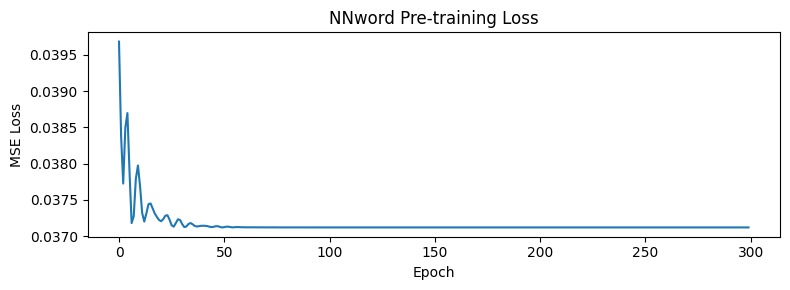

Stage 1 完成


In [8]:
model_word = NNword(N_SEEDS)
opt_word   = optim.Adam(model_word.parameters(), lr=0.001, weight_decay=0.001)
sch_word   = optim.lr_scheduler.StepLR(opt_word, step_size=100, gamma=0.5)

print('=== Stage 1：預訓練 NNword ===')
losses_w = []
for epoch in range(300):
    model_word.train()
    pred_v, pred_a = model_word(Sw_t, Xv_t, Xa_t)
    loss = 0.5 * ((pred_v - yv_t)**2 + (pred_a - ya_t)**2).mean()
    opt_word.zero_grad()
    loss.backward()
    opt_word.step()
    sch_word.step()
    losses_w.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | Loss: {loss.item():.6f}')

plt.figure(figsize=(8,3))
plt.plot(losses_w)
plt.title('NNword Pre-training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Stage 1 完成')

## 7. 準備 NNmod 訓練資料（CVAP 片語）
**v4 關鍵：** 核心詞的 Sw 張量也一起預先計算好，
聯合訓練時直接透過 NNword.forward 取得 Int(w)，不查表。

In [9]:
print('建立 CVAP 訓練資料...')

# 為每個 CVAP 訓練片語的核心詞預先算好 Sw 張量
Sw_core_list = []
vm_list      = []
tgt_v_list   = []
tgt_a_list   = []
Xv_core_list = []
Xa_core_list = []

for _, row in cvap_train.iterrows():
    core = row['core_word']
    mod  = row['modifier']

    # 核心詞的相似度向量（用來給 NNword 即時計算 Int(w)）
    tv   = get_vec(core)
    sims = np.array([cosine_sim(tv, sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)

    Sw_core_list.append(sims)
    Xv_core_list.append(seed_val.copy())
    Xa_core_list.append(seed_aro.copy())
    vm_list.append(get_vec(mod))
    tgt_v_list.append([row['valence']])
    tgt_a_list.append([row['arousal']])

Sw_core_t  = torch.tensor(np.array(Sw_core_list, dtype=np.float32))
Xv_core_t  = torch.tensor(np.array(Xv_core_list, dtype=np.float32))
Xa_core_t  = torch.tensor(np.array(Xa_core_list, dtype=np.float32))
vm_t       = torch.tensor(np.array(vm_list,      dtype=np.float32))
tgt_v_t    = torch.tensor(np.array(tgt_v_list,   dtype=np.float32))
tgt_a_t    = torch.tensor(np.array(tgt_a_list,   dtype=np.float32))
print(f'CVAP 訓練樣本數: {len(tgt_v_list)}  完成')

建立 CVAP 訓練資料...
CVAP 訓練樣本數: 1799  完成


## 8. Stage 2：NNword + NNmod 聯合訓練（End-to-End Pipeline）
**這是 v4 和 v3 最大的差別：**
- NNmod 訓練時，Int(w) 由 NNword.forward 即時計算，不查表
- loss.backward() 同時更新兩個模型的參數
- 梯度從 NNmod 透過 Int(w) 一路反傳回 NNword

=== Stage 2：NNword + NNmod 聯合訓練（End-to-End）===
Epoch  100 | Loss: 0.024462
Epoch  200 | Loss: 0.024338
Epoch  300 | Loss: 0.024361
Epoch  400 | Loss: 0.024332
Epoch  500 | Loss: 0.024344
Epoch  600 | Loss: 0.024335
Epoch  700 | Loss: 0.024344
Epoch  800 | Loss: 0.024368


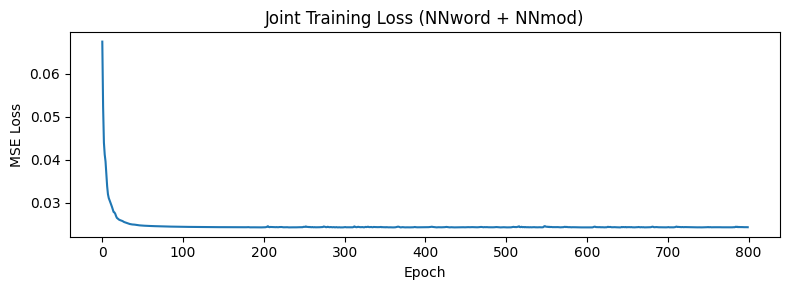

Stage 2 完成


In [10]:
model_mod  = NNmod(VEC_DIM)

# 兩個模型用各自的優化器，但同一個 loss 一起更新
opt_word2  = optim.Adam(model_word.parameters(), lr=0.0001, weight_decay=0.001)  # NNword 用小 lr 微調
opt_mod    = optim.Adam(model_mod.parameters(),  lr=0.005,  weight_decay=0.0001)

print('=== Stage 2：NNword + NNmod 聯合訓練（End-to-End）===')
losses_joint = []
for epoch in range(800):
    model_word.train()
    model_mod.train()

    # ── 核心：NNword 即時輸出 Int(w)，直接餵給 NNmod ──
    # 不查表，讓梯度可以從 NNmod 反傳回 NNword
    int_val, int_aro = model_word(Sw_core_t, Xv_core_t, Xa_core_t)

    # NNmod 接收 NNword 的輸出
    pred_v, pred_a, _ = model_mod(int_val, int_aro, vm_t)

    # 對片語 VA 計算 loss
    loss = 0.5 * ((pred_v - tgt_v_t)**2 + (pred_a - tgt_a_t)**2).mean()

    # 兩個模型同時更新
    opt_word2.zero_grad()
    opt_mod.zero_grad()
    loss.backward()      # 梯度同時傳回兩個模型
    opt_word2.step()
    opt_mod.step()

    losses_joint.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | Loss: {loss.item():.6f}')

plt.figure(figsize=(8,3))
plt.plot(losses_joint)
plt.title('Joint Training Loss (NNword + NNmod)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Stage 2 完成')

## 9. 預測函式

In [11]:
def predict_word_va(word, k=15):
    """
    單詞 VA 預測：
    - 訓練集已知詞：直接查表
    - 測試集未知詞：kNN k=15 加權平均
    """
    if word in cvaw_dict:
        d = cvaw_dict[word]
        return d['valence'], d['arousal'], '(訓練集已知)'
    tv   = get_vec(word)
    sims = np.array([cosine_sim(tv, sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)
    topk_idx = np.argsort(sims)[-k:]
    topk_sim = sims[topk_idx]
    total    = topk_sim.sum()
    if total < 1e-9:
        return 0.5, 0.5, '(無相似詞)'
    weights = topk_sim / total
    pred_v  = float(np.dot(weights, seed_val[topk_idx]))
    pred_a  = float(np.dot(weights, seed_aro[topk_idx]))
    return pred_v, pred_a, f'(kNN k={k})'


def predict_phrase_va_pipeline(modifier, core_word, verbose=False):
    """
    完整 Pipeline 預測（v4）：
    NNword.forward → Int(w) → NNmod.forward → Int(mod w)
    兩個模型真正串接，不查表
    """
    # Step 1：用 NNword 即時計算核心詞 VA
    tv   = get_vec(core_word)
    sims = np.array([cosine_sim(tv, sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)

    model_word.eval()
    model_mod.eval()
    with torch.no_grad():
        Sw_in  = torch.tensor(sims).unsqueeze(0)
        Xv_in  = torch.tensor(seed_val).unsqueeze(0)
        Xa_in  = torch.tensor(seed_aro).unsqueeze(0)

        # NNword 輸出 Int(w)
        int_val, int_aro = model_word(Sw_in, Xv_in, Xa_in)

        # Step 2：NNmod 接收 Int(w) 輸出 Int(mod w)
        vm_in = torch.tensor(get_vec(modifier), dtype=torch.float32).unsqueeze(0)
        pred_v, pred_a, c_mod = model_mod(int_val, int_aro, vm_in)

    pv = pred_v.item()
    pa = pred_a.item()
    iv = int_val.item()
    ia = int_aro.item()
    cm = c_mod.item()

    if verbose:
        print(f'「{modifier}{core_word}」'
              f'  NNword→({iv:.3f},{ia:.3f})'
              f'  C(mod)={cm:.3f}'
              f'  → V={pv:.4f} A={pa:.4f}')
    return pv, pa


def va_label(v, a):
    pol = '正向' if v>=0.625 else ('負向' if v<=0.375 else '中性')
    act = '高喚起' if a>=0.625 else ('低喚起' if a<=0.375 else '中喚起')
    return f'{pol}/{act}'


# 測試串接預測
print('=== Pipeline 串接預測測試 ===')
for mod, word in [('非常','開心'),('沒有','希望'),('完全','不滿意'),('極為','不安'),('相當','平靜')]:
    pv, pa = predict_phrase_va_pipeline(mod, word, verbose=True)
    print(f'  → {va_label(pv, pa)}')

=== Pipeline 串接預測測試 ===
「非常開心」  NNword→(0.422,0.567)  C(mod)=0.780  → V=0.6281 A=0.7429
  → 正向/高喚起
「沒有希望」  NNword→(0.422,0.567)  C(mod)=0.554  → V=0.4621 A=0.4158
  → 中性/中喚起
「完全不滿意」  NNword→(0.422,0.567)  C(mod)=0.576  → V=0.4786 A=0.6031
  → 中性/中喚起
「極為不安」  NNword→(0.422,0.567)  C(mod)=0.535  → V=0.4477 A=0.7725
  → 中性/高喚起
「相當平靜」  NNword→(0.422,0.567)  C(mod)=0.666  → V=0.5459 A=0.7089
  → 中性/高喚起


## 10. 評估函式（MAE / MSE / Pearson r / Kendall τ / Spearman ρ）

In [12]:
def compute_metrics(preds, golds, label):
    """
    Chinese EmoBank 論文指標：MAE、Pearson r
    Pipelined NN 論文指標：Kendall τ、Spearman ρ
    額外加入：MSE
    """
    p = np.array(preds)
    g = np.array(golds)
    mae      = np.mean(np.abs(p - g))
    mse      = np.mean((p - g) ** 2)
    r, _     = pearsonr(p, g)
    tau, _   = kendalltau(p, g)
    rho, _   = spearmanr(p, g)
    print(f'  {label:30s} | MAE={mae:.4f}  MSE={mse:.4f}  r={r:.4f}  τ={tau:.4f}  ρ={rho:.4f}')
    return mae, mse, r, tau, rho

## 11. 訓練集評估

In [13]:
print('='*75)
print('【訓練集評估】')
print('='*75)

# NNword 訓練集（CVAW train）
print('\n[NNword] CVAW 訓練集')
pv_trw, pa_trw, gv_trw, ga_trw = [], [], [], []
for _, row in cvaw_train.iterrows():
    v, a, _ = predict_word_va(row['Word'])
    pv_trw.append(v); pa_trw.append(a)
    gv_trw.append(row['valence']); ga_trw.append(row['arousal'])
compute_metrics(pv_trw, gv_trw, 'Valence')
compute_metrics(pa_trw, ga_trw, 'Arousal')

# NNmod Pipeline 訓練集（CVAP train）
print('\n[Pipeline] CVAP 訓練集')
pv_trm, pa_trm, gv_trm, ga_trm = [], [], [], []
for _, row in cvap_train.iterrows():
    v, a = predict_phrase_va_pipeline(row['modifier'], row['core_word'])
    pv_trm.append(v); pa_trm.append(a)
    gv_trm.append(row['valence']); ga_trm.append(row['arousal'])
compute_metrics(pv_trm, gv_trm, 'Valence')
compute_metrics(pa_trm, ga_trm, 'Arousal')

【訓練集評估】

[NNword] CVAW 訓練集
  Valence                        | MAE=0.0000  MSE=0.0000  r=1.0000  τ=1.0000  ρ=1.0000
  Arousal                        | MAE=0.0000  MSE=0.0000  r=1.0000  τ=1.0000  ρ=1.0000

[Pipeline] CVAP 訓練集
  Valence                        | MAE=0.1453  MSE=0.0380  r=0.4834  τ=0.3381  ρ=0.4411
  Arousal                        | MAE=0.0790  MSE=0.0109  r=0.7256  τ=0.5486  ρ=0.7397


(np.float64(0.07897552691279947),
 np.float64(0.01090295990062217),
 np.float64(0.7256410370289883),
 np.float64(0.5486012752650393),
 np.float64(0.7396728647242656))

## 12. 測試集評估

In [14]:
print('='*75)
print('【測試集評估】')
print('='*75)

# NNword 測試集（CVAW test）
print('\n[NNword] CVAW 測試集')
pv_tew, pa_tew, gv_tew, ga_tew = [], [], [], []
for _, row in cvaw_test.iterrows():
    v, a, _ = predict_word_va(row['Word'])
    pv_tew.append(v); pa_tew.append(a)
    gv_tew.append(row['valence']); ga_tew.append(row['arousal'])
compute_metrics(pv_tew, gv_tew, 'Valence')
compute_metrics(pa_tew, ga_tew, 'Arousal')

# Pipeline 測試集（CVAP test）
print('\n[Pipeline] CVAP 測試集')
pv_tem, pa_tem, gv_tem, ga_tem = [], [], [], []
for _, row in cvap_test.iterrows():
    v, a = predict_phrase_va_pipeline(row['modifier'], row['core_word'])
    pv_tem.append(v); pa_tem.append(a)
    gv_tem.append(row['valence']); ga_tem.append(row['arousal'])
compute_metrics(pv_tem, gv_tem, 'Valence')
compute_metrics(pa_tem, ga_tem, 'Arousal')

【測試集評估】

[NNword] CVAW 測試集
  Valence                        | MAE=0.1694  MSE=0.0401  r=0.2370  τ=0.1508  ρ=0.2228
  Arousal                        | MAE=0.1471  MSE=0.0317  r=0.1629  τ=0.0924  ρ=0.1355

[Pipeline] CVAP 測試集
  Valence                        | MAE=0.1624  MSE=0.0450  r=0.3053  τ=0.1942  ρ=0.2564
  Arousal                        | MAE=0.0862  MSE=0.0126  r=0.6752  τ=0.4848  ρ=0.6729


(np.float64(0.08618952452129788),
 np.float64(0.012574434771788746),
 np.float64(0.6751686683802888),
 np.float64(0.4848117875138846),
 np.float64(0.6729261463495374))

## 13. 結果摘要表 + 視覺化

In [15]:
def metrics(p, g):
    pa = np.array(p); ga = np.array(g)
    mae    = np.mean(np.abs(pa - ga))
    mse    = np.mean((pa - ga)**2)
    r, _   = pearsonr(pa, ga)
    tau, _ = kendalltau(pa, ga)
    rho, _ = spearmanr(pa, ga)
    return round(mae,4), round(mse,4), round(r,4), round(tau,4), round(rho,4)

rows = [
    ('NNword',   '訓練', 'Valence', *metrics(pv_trw, gv_trw)),
    ('NNword',   '訓練', 'Arousal', *metrics(pa_trw, ga_trw)),
    ('NNword',   '測試', 'Valence', *metrics(pv_tew, gv_tew)),
    ('NNword',   '測試', 'Arousal', *metrics(pa_tew, ga_tew)),
    ('Pipeline', '訓練', 'Valence', *metrics(pv_trm, gv_trm)),
    ('Pipeline', '訓練', 'Arousal', *metrics(pa_trm, ga_trm)),
    ('Pipeline', '測試', 'Valence', *metrics(pv_tem, gv_tem)),
    ('Pipeline', '測試', 'Arousal', *metrics(pa_tem, ga_tem)),
]
summary = pd.DataFrame(rows,
    columns=['模型','資料集','維度','MAE','MSE','Pearson r','Kendall τ','Spearman ρ'])
print(summary.to_string(index=False))

      模型 資料集      維度    MAE    MSE  Pearson r  Kendall τ  Spearman ρ
  NNword  訓練 Valence 0.0000 0.0000     1.0000     1.0000      1.0000
  NNword  訓練 Arousal 0.0000 0.0000     1.0000     1.0000      1.0000
  NNword  測試 Valence 0.1694 0.0401     0.2370     0.1508      0.2228
  NNword  測試 Arousal 0.1471 0.0317     0.1629     0.0924      0.1355
Pipeline  訓練 Valence 0.1453 0.0380     0.4834     0.3381      0.4411
Pipeline  訓練 Arousal 0.0790 0.0109     0.7256     0.5486      0.7397
Pipeline  測試 Valence 0.1624 0.0450     0.3053     0.1942      0.2564
Pipeline  測試 Arousal 0.0862 0.0126     0.6752     0.4848      0.6729


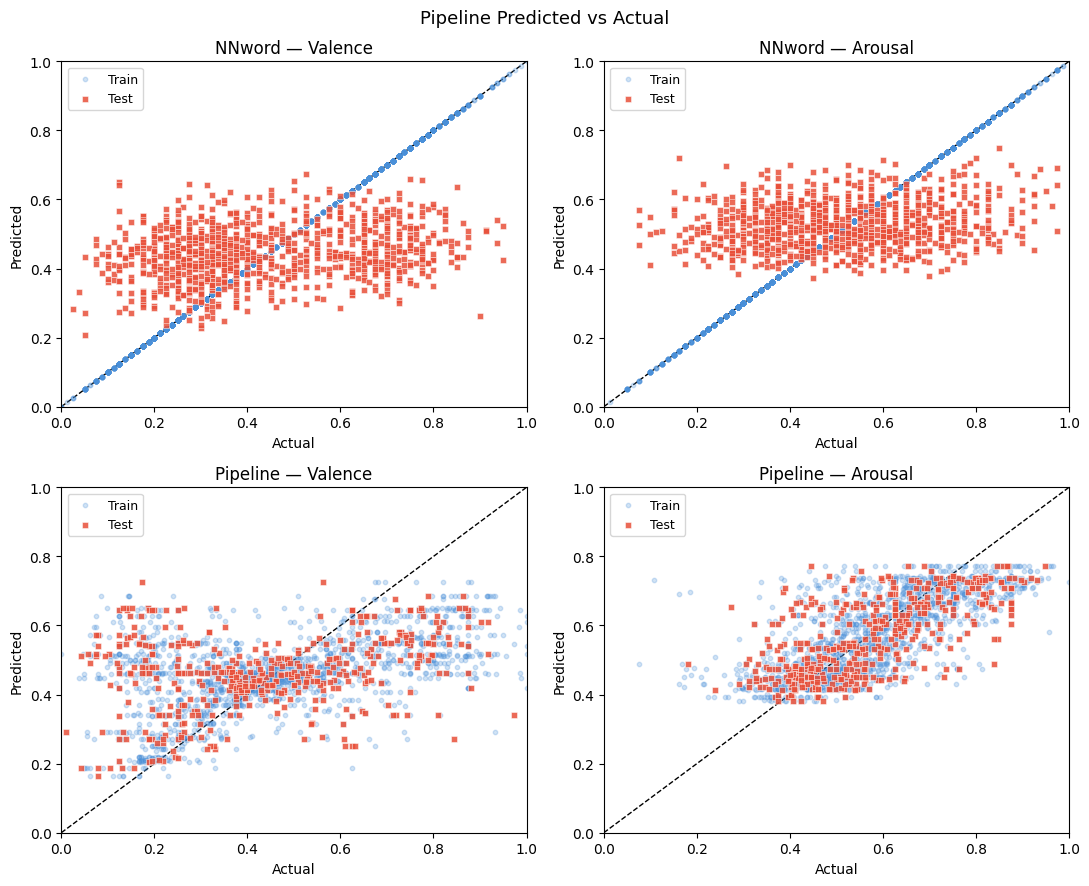

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('Pipeline Predicted vs Actual', fontsize=13)

configs = [
    (axes[0,0], pv_trw, gv_trw, pv_tew, gv_tew, 'NNword — Valence',
     '#4A90D9', '#E8503A'),   # 訓練=藍  測試=紅
    (axes[0,1], pa_trw, ga_trw, pa_tew, ga_tew, 'NNword — Arousal',
     '#4A90D9', '#E8503A'),
    (axes[1,0], pv_trm, gv_trm, pv_tem, gv_tem, 'Pipeline — Valence',
     '#4A90D9', '#E8503A'),
    (axes[1,1], pa_trm, ga_trm, pa_tem, ga_tem, 'Pipeline — Arousal',
     '#4A90D9', '#E8503A'),
]

for ax, ptr, gtr, pte, gte, title, c_train, c_test in configs:
    # 訓練集：藍色圓點
    ax.scatter(gtr, ptr, alpha=0.25, s=10, color=c_train,
               label='Train', zorder=2)
    # 測試集：紅色方塊，更大更清楚
    ax.scatter(gte, pte, alpha=0.85, s=20, color=c_test,
               marker='s', edgecolors='white', linewidths=0.4,
               label='Test', zorder=3)
    ax.plot([0,1],[0,1],'k--', linewidth=1, zorder=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## 14. 互動預測

In [17]:
# 單詞預測
print('=== 單詞預測 ===')
for w in ['開心','難過','憤怒','平靜','興奮','恐懼']:
    v, a, src = predict_word_va(w)
    print(f'「{w}」V={v:.4f} A={a:.4f} → {va_label(v,a)}  {src}')

print()

# Pipeline 片語預測
print('=== Pipeline 片語預測（NNword→NNmod 串接）===')
for mod, word in [('非常','開心'),('沒有','希望'),('完全','不滿意'),
                  ('極為','不安'),('相當','平靜'),('可能','失望')]:
    pv, pa = predict_phrase_va_pipeline(mod, word, verbose=True)
    print(f'  → {va_label(pv, pa)}')

=== 單詞預測 ===
「開心」V=0.7750 A=0.7000 → 正向/高喚起  (訓練集已知)
「難過」V=0.2500 A=0.5750 → 負向/中喚起  (訓練集已知)
「憤怒」V=0.2000 A=0.7000 → 負向/高喚起  (訓練集已知)
「平靜」V=0.6750 A=0.1750 → 正向/低喚起  (訓練集已知)
「興奮」V=0.8000 A=0.7750 → 正向/高喚起  (訓練集已知)
「恐懼」V=0.2000 A=0.7250 → 負向/高喚起  (訓練集已知)

=== Pipeline 片語預測（NNword→NNmod 串接）===
「非常開心」  NNword→(0.422,0.567)  C(mod)=0.780  → V=0.6281 A=0.7429
  → 正向/高喚起
「沒有希望」  NNword→(0.422,0.567)  C(mod)=0.554  → V=0.4621 A=0.4158
  → 中性/中喚起
「完全不滿意」  NNword→(0.422,0.567)  C(mod)=0.576  → V=0.4786 A=0.6031
  → 中性/中喚起
「極為不安」  NNword→(0.422,0.567)  C(mod)=0.535  → V=0.4477 A=0.7725
  → 中性/高喚起
「相當平靜」  NNword→(0.422,0.567)  C(mod)=0.666  → V=0.5459 A=0.7089
  → 中性/高喚起
「可能失望」  NNword→(0.422,0.567)  C(mod)=0.574  → V=0.4766 A=0.4913
  → 中性/中喚起


## 15. 多修飾詞遞迴預測（論文 Section 3.3）

In [18]:
def predict_multi_mod_pipeline(modifiers, core_word):
    """
    多修飾詞遞迴：每層都透過 NNword→NNmod 完整 Pipeline
    由最靠近核心詞的修飾詞開始，逐層向外套用
    """
    phrase_str = ''.join(modifiers) + core_word
    print(f'\n多修飾詞片語：「{phrase_str}」')

    # 第一層：核心詞 VA 由 NNword 計算
    tv   = get_vec(core_word)
    sims = np.array([cosine_sim(tv, sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)

    model_word.eval(); model_mod.eval()
    with torch.no_grad():
        cur_v, cur_a = model_word(
            torch.tensor(sims).unsqueeze(0),
            torch.tensor(seed_val).unsqueeze(0),
            torch.tensor(seed_aro).unsqueeze(0)
        )
        cur_v = cur_v.item()
        cur_a = cur_a.item()

    cur_label = core_word

    for mod in reversed(modifiers):
        with torch.no_grad():
            vm_in = torch.tensor(get_vec(mod), dtype=torch.float32).unsqueeze(0)
            pred_v, pred_a, c_mod = model_mod(
                torch.tensor([[cur_v]], dtype=torch.float32),
                torch.tensor([[cur_a]], dtype=torch.float32),
                vm_in
            )
            new_v = pred_v.item()
            new_a = pred_a.item()
            cm    = c_mod.item()

        print(f'  +「{mod}」→ V:{cur_v:.4f}→{new_v:.4f}  '
              f'A:{cur_a:.4f}→{new_a:.4f}  [C={cm:.3f}]')
        cur_v, cur_a = new_v, new_a
        cur_label = mod + cur_label

    print(f'  最終 → V={cur_v:.4f}  A={cur_a:.4f}  {va_label(cur_v, cur_a)}')
    return cur_v, cur_a


predict_multi_mod_pipeline(['應該','沒有','非常'], '開心')
predict_multi_mod_pipeline(['完全','不'],          '滿意')
predict_multi_mod_pipeline(['可能','更加'],        '不安')


多修飾詞片語：「應該沒有非常開心」
  +「非常」→ V:0.4219→0.6281  A:0.5666→0.7429  [C=0.780]
  +「沒有」→ V:0.6281→0.6653  A:0.7429→0.6114  [C=0.554]
  +「應該」→ V:0.6653→0.7554  A:0.6114→0.5658  [C=0.647]
  最終 → V=0.7554  A=0.5658  正向/中喚起

多修飾詞片語：「完全不滿意」
  +「不」→ V:0.4219→0.3845  A:0.5666→0.5324  [C=0.448]
  +「完全」→ V:0.3845→0.4399  A:0.5324→0.5696  [C=0.576]
  最終 → V=0.4399  A=0.5696  中性/中喚起

多修飾詞片語：「可能更加不安」
  +「更加」→ V:0.4219→0.5672  A:0.5666→0.6824  [C=0.695]
  +「可能」→ V:0.5672→0.6205  A:0.6824→0.6135  [C=0.574]
  最終 → V=0.6205  A=0.6135  中性/中喚起


(0.6204767823219299, 0.613525927066803)